In [1]:
import pandas as pd
import numpy as np
import os
import math
from pathlib import Path
from matplotlib import pyplot as plt
idx = pd.IndexSlice
import xarray as xr
from read_mym import read_mym_df
from util import dataset_to_array

from constants_BUMA import(
    SCENARIO_SELECT, FILE_ADDITION,
    REGIONS, REGIONS_RANGE,
    START_YEAR, END_YEAR, HIST_YEAR, YEARS, YEAR_LIST_SVA,
    INFLATION, 
    FLAG_ALPHA, FLAG_EXPDEC, FLAG_NORMAL,
    LOWCOMM,
    GOMPERTZ_EXPDEC,
    MINIMUM_COM
)


In [2]:
base_directory = Path("..", "IMAGE-Mat_old_version", "IMAGE-Mat", "BUMA")
database_directory = base_directory / "files_DB" / SCENARIO_SELECT
image_directory = base_directory / "files_IMAGE" / SCENARIO_SELECT
assert database_directory.is_dir(), database_directory
assert image_directory.is_dir()

In [3]:
# Pop; unit: million of people; meaning: global population (over time, by region)             
population: pd.DataFrame = pd.read_csv(image_directory.joinpath('pop.csv'), index_col = [0]) 
# rurpop; unit: %; meaning: the share of people living in rural areas (over time, by region)
rural_population: pd.DataFrame = pd.read_csv(image_directory. joinpath('rurpop.csv'), index_col = [0])
# load historic population development
historic_population = pd.read_csv(base_directory / 'files_initial_stock' /'hist_pop.csv', index_col = [0])  
# initial population as a percentage of the 1970 population; unit: %; according to the Maddison Project Database (MPD) 2018 (Groningen University)


In [4]:
# Interpolate population and rural population data (fills in missing years with cubic interpolation)
rural_population = rural_population.reindex(YEARS).interpolate(method='cubic')
population = population.reindex(YEARS).interpolate(method='cubic')
# Remove 1st year, to ensure same Table size as floorspace data (from 1971)
#population = population.iloc[1:]
#rural_population = rural_population.iloc[1:]
#TODO unsure why first vakue is removed

#pre-calculate urban population
urban_population = 1 - rural_population    
# urban population is 1 - the fraction of people living in rural areas (rural_population)


In [5]:
# Deriving historic population tail based on fraction for 1970
population_1970 = population.loc[1970]
historic_population = historic_population.multiply(population_1970, axis=1)
population = pd.concat([historic_population.loc[:1969], population])

In [6]:
# Get the growth or rural population by year (average for the first 10 years of IMAGE data)
rural_population_trend = ((1-rural_population.loc[1980]/rural_population.loc[1970])/10)*100
maximum_rural_population = rural_population.values.max()

In [7]:
population = population.rename_axis(index = "Year", columns = "Region")

In [8]:
population_array = xr.DataArray(
    data=population.values,               # Data values from the DataFrame
    dims=["Year", "Region"],       # Names for the two dimensions
    coords={"Year": population.index,      # Year coordinates from the DataFrame index
            "Region": population.columns}  # Region coordinates from the DataFrame columns
    )

In [9]:
far_start_year = 1721
start_year = 1820
end_year = 1970

years_1721_1820 = xr.DataArray(np.arange(far_start_year, start_year), dims=["Year"], coords={"Year": np.arange(far_start_year, start_year)})
years_1820_1970 = xr.DataArray(np.arange(start_year, end_year), dims=["Year"], coords={"Year": np.arange(start_year, end_year)})

In [10]:
population_1721_1820 = (population_array[0]*(1-(start_year - years_1721_1820)/(start_year-far_start_year+1))).transpose()

In [11]:
population_xr = xr.concat((population_1721_1820, population_array), dim="Year")

In [12]:
rurpop_share_1970_future = dataset_to_array(rural_population.to_xarray(), ["Year"], ["Region"])
rurpop_trend_xr = rural_population_trend.to_xarray().rename({"index": "Region"})

In [13]:
rurpop_share_1820_1970 = (rurpop_share_1970_future.loc[1970] * ((100+rurpop_trend_xr)/100)**(1970-years_1820_1970)).transpose()
rurpop_share_1820_1970 = rurpop_share_1820_1970.where(rurpop_share_1820_1970 <= maximum_rural_population, maximum_rural_population)

In [14]:
rurpop_share_1721_1820 = rurpop_share_1820_1970.loc[1820] - (rurpop_share_1820_1970.loc[1820])*(1820-years_1721_1820)/100
rurpop_share_1721_1820 = rurpop_share_1721_1820.transpose()
rurpop_share_1721_1820 = rurpop_share_1721_1820.where(rurpop_share_1721_1820 >= 0, 0)

In [15]:
rurpop_share = xr.concat((rurpop_share_1721_1820, rurpop_share_1820_1970, rurpop_share_1970_future), dim="Year")
urbpop_share = 1-rurpop_share

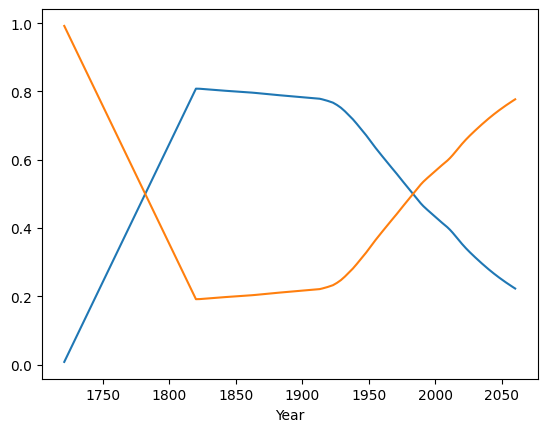

In [16]:
rurpop_share.mean("Region").plot()
urbpop_share.mean("Region").plot()

In [17]:
rurpop = rurpop_share*population_xr
urbpop = urbpop_share*population_xr

In [18]:
all_population_xr = xr.concat((population_xr, rurpop, urbpop), dim="Location").assign_coords({"Location": ["Total", "Rural", "Urban"]}).transpose("Year", "Region", "Location")

In [28]:
from population import compute_population, compute_rurpop_share, compute_total_population

# Compute total/rural/urban populations
compute_population()

<xarray.DataArray (Year: 340, Region: 26, Location: 3)> Size: 212kB
array([[[8.04857371e-03, 2.44813725e-03, 9.97551863e-01],
        [1.55674801e-02, 6.22929145e-03, 9.93770709e-01],
        [1.39545197e+00, 8.87653886e-03, 9.91123461e-01],
        ...,
        [1.13517223e-01, 8.87653886e-03, 9.91123461e-01],
        [1.88283421e-01, 8.87653886e-03, 9.91123461e-01],
        [1.53842258e-01, 8.87653886e-03, 9.91123461e-01]],

       [[1.60971474e-02, 4.89627450e-03, 9.95103726e-01],
        [3.11349603e-02, 1.24585829e-02, 9.87541417e-01],
        [2.79090394e+00, 1.77530777e-02, 9.82246922e-01],
        ...,
        [2.27034446e-01, 1.77530777e-02, 9.82246922e-01],
        [3.76566842e-01, 1.77530777e-02, 9.82246922e-01],
        [3.07684516e-01, 1.77530777e-02, 9.82246922e-01]],

       [[2.41457211e-02, 7.34441174e-03, 9.92655588e-01],
        [4.67024404e-02, 1.86878744e-02, 9.81312126e-01],
        [4.18635591e+00, 2.66296166e-02, 9.73370383e-01],
        ...,
...
        ...,
        [2.51066444e+02, 2.61349099e-01, 7.38650901e-01],
        [1.01810109e+03, 3.34826544e-01, 6.65173456e-01],
        [6.15200189e+02, 5.33013009e-01, 4.66986991e-01]],

       [[5.03156408e+01, 7.81828145e-02, 9.21817185e-01],
        [6.73812596e+01, 1.99728193e-01, 8.00271807e-01],
        [4.61091034e+02, 1.11337339e-01, 8.88662661e-01],
        ...,
        [2.51479915e+02, 2.58623696e-01, 7.41376304e-01],
        [1.02874685e+03, 3.31591970e-01, 6.68408030e-01],
        [6.20872112e+02, 5.28375908e-01, 4.71624092e-01]],

       [[5.05944800e+01, 7.67071280e-02, 9.23292872e-01],
        [6.74555900e+01, 1.97554729e-01, 8.02445271e-01],
        [4.61442300e+02, 1.09760068e-01, 8.90239932e-01],
        ...,
        [2.51840300e+02, 2.55938450e-01, 7.44061550e-01],
        [1.03924800e+03, 3.28403959e-01, 6.71596041e-01],
        [6.26426700e+02, 5.23756637e-01, 4.76243363e-01]]])
Coordinates:
  * Year      (Year) int64 3kB 1721 1722 1723 1724 1725 ... 2057 2058 2059 2060
  * Region    (Region) object 208B '1' '10' '11' '12' '13' ... '6' '7' '8' '9'
  * Location  (Location) <U5 60B 'Total' 'Rural' 'Urban'